# 2 · Survival fine-mapping (Cox & AFT)

Here the phenotype is a **survival time** with **right-censoring** — some individuals
have not had the event by the end of follow-up, so we only know their time exceeds a
threshold. `lasusie` ships two families of survival likelihoods:

- **`cox(times, events)`** — the Cox proportional-hazards *partial* likelihood. It is a
  *composite* likelihood: the risk-set denominators couple all individuals, so it does
  not factorise. No baseline hazard is estimated.
- **`aft_weibull` / `aft_lognormal` / `aft_loglogistic`** — *parametric*
  accelerated-failure-time models. These *do* factorise over individuals (censoring
  folded in per observation), so they get exact Gauss-Hermite variance propagation.

Both slot into the same `Model` — only the likelihood axis changes.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context="notebook", style="whitegrid")
rng = np.random.default_rng(0)  # NumPy RNG for the simulations (deterministic)

In [2]:
def plot_pips(pip, causal, title, ax=None):
    """Stem plot of per-variant PIPs, with the true causal variants highlighted."""
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 3))
    m = np.arange(len(pip))
    ax.vlines(m, 0, pip, color="0.75", lw=1)
    ax.scatter(m, pip, s=12, color="0.4", label="variants")
    ax.scatter(causal, np.asarray(pip)[list(causal)], s=70, color="crimson",
               zorder=3, label="true causal")
    ax.set(xlabel="variant index", ylabel="PIP", ylim=(-0.02, 1.05), title=title)
    ax.legend(loc="upper right", frameon=True)
    return ax


def credible_set_table(result):
    """Tidy DataFrame summarising the credible sets that passed the purity filter."""
    rows = []
    for cs in result.credible_sets:
        if not cs.kept:
            continue
        rows.append({
            "effect": cs.effect,
            "size": len(cs.variants),
            "coverage": round(float(cs.coverage), 3),
            "purity": round(float(cs.purity), 3),
            "variants": list(np.asarray(cs.variants)[:8]),
        })
    return pd.DataFrame(rows)


## Simulate survival times with a causal variant

We plant a single causal variant `j` driving the linear predictor `eta = X[:, j] * beta`.
Event times are exponential with hazard `exp(eta)` (a proportional-hazards truth), and we
apply independent random censoring so ~30% of individuals are censored.

In [3]:
N, M, j = 400, 60, 20
X = rng.standard_normal((N, M))
X = (X - X.mean(0)) / X.std(0)

beta = 1.3
eta_true = X[:, j] * beta

# Exponential event times with hazard exp(eta):  T = -log(U) / exp(eta)
U = rng.uniform(1e-6, 1.0, size=N)
event_time = -np.log(U) / np.exp(eta_true)

# Independent censoring times -> observe min(event, censor)
censor_time = rng.exponential(scale=np.quantile(event_time, 0.8), size=N)
times = np.minimum(event_time, censor_time)
events = (event_time <= censor_time).astype(float)   # 1 = observed, 0 = censored
print(f"observed events: {events.mean():.0%}   causal variant: {j}")

observed events: 66%   causal variant: 20


## Cox proportional hazards

The Cox likelihood needs only the times and the event indicator. Everything else — prior,
design, inclusion weights — is identical to the Gaussian case.

> Cox is a *composite* likelihood, so its offset-variance propagation goes through a
> delta-method correction that needs the diagonal of the log-likelihood Hessian. The
> Hessian is dense (the risk sets couple all `N` individuals), but `CoxPH.hessian_diagonal`
> computes just its diagonal in `O(N)` via reverse cumulative sums over the risk sets —
> the same trick the log-likelihood itself uses — instead of materialising the full `N x N`
> matrix. So the variance-propagating default (`propagate_variance=True`) is cheap here;
> pass `propagate_variance=False` only if you want to skip the correction entirely.

In [ ]:
from lasusie import finemap, Model, likelihoods, priors
from lasusie.design import SharedDesign

Xj = jnp.asarray(X)
cox_model = Model(
    design=SharedDesign(X=Xj),
    likelihood=likelihoods.cox(jnp.asarray(times), jnp.asarray(events)),
    prior=priors.susie(sigma0_sq=1.0),
    log_pi=jnp.full(M, -jnp.log(M)),
)
# propagate_variance defaults to True; the O(N) hessian_diagonal keeps it cheap for Cox.
cox_res = finemap(cox_model, L=3, coverage=0.95, purity=0.5)
print(f"Cox: top variant = {int(np.argmax(cox_res.pip))}  (true = {j}),  "
      f"PIP = {cox_res.pip[j]:.3f}")

## Parametric AFT (Weibull)

A Weibull AFT models `log T = eta + scale * W` with an extreme-value error. Same data,
different likelihood — note it takes the same `(times, events)` plus a fixed `scale`.

In [5]:
aft_model = Model(
    design=SharedDesign(X=Xj),
    likelihood=likelihoods.aft_weibull(jnp.asarray(times), jnp.asarray(events), scale=1.0),
    prior=priors.susie(sigma0_sq=1.0),
    log_pi=jnp.full(M, -jnp.log(M)),
)
aft_res = finemap(aft_model, L=3, coverage=0.95, purity=0.5)
print(f"AFT-Weibull: top variant = {int(np.argmax(aft_res.pip))}  (true = {j}),  "
      f"PIP = {aft_res.pip[j]:.3f}")

AFT-Weibull: top variant = 20  (true = 20),  PIP = 1.000


## Compare the two survival models

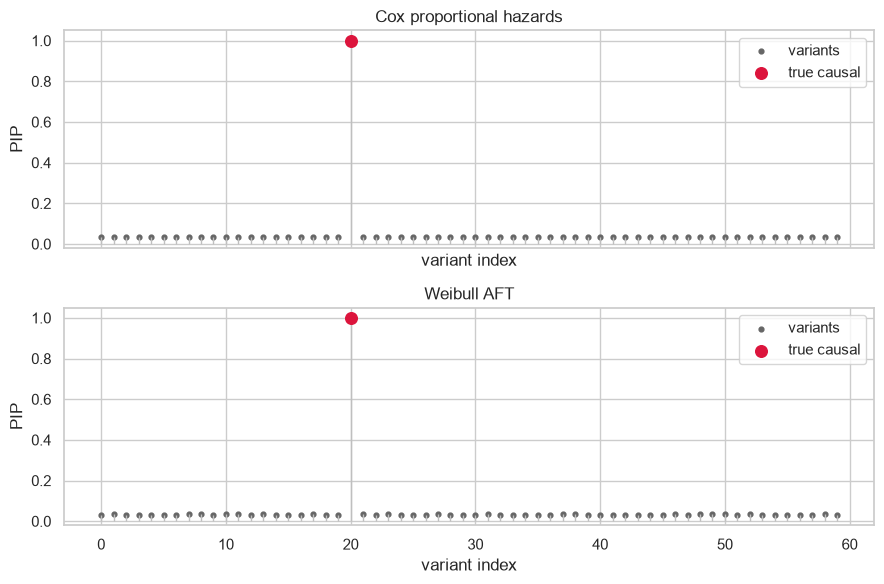

Cox credible sets:


,effect,size,coverage,purity,variants
0,0,1,1.0,1.0,[20]


AFT-Weibull credible sets:


,effect,size,coverage,purity,variants
0,0,1,1.0,1.0,[20]


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
plot_pips(cox_res.pip, [j], "Cox proportional hazards", ax=axes[0])
plot_pips(aft_res.pip, [j], "Weibull AFT", ax=axes[1])
plt.tight_layout(); plt.show()

print("Cox credible sets:");        display(credible_set_table(cox_res))
print("AFT-Weibull credible sets:"); display(credible_set_table(aft_res))

Both survival models concentrate the PIP on the true causal variant despite ~30%
censoring. Cox makes no assumption about the baseline hazard shape; the parametric AFT
is cheaper (it factorises) and additionally gives you an interpretable time-scale via
`scale`. Swap `aft_weibull` for `aft_lognormal` or `aft_loglogistic` to change the
baseline error distribution.